# Trabalho Final — Propensão de Contratação de Consultoria (Sebrae RN)

Lucas Medeiros — Aprendizado Profundo, PPgTI/IMD/UFRN, Prof. Josenalde Oliveira

## O problema

O Sebrae/RN atende milhares de empresas por ano, mas o contato comercial é um recurso limitado. Hoje
não existe critério para decidir a quem oferecer uma consultoria: quem chuta acerta na taxa-base da
população, **cerca de 2,5%** — uma contratação a cada 40 abordagens.

Este trabalho treina uma rede neural para responder uma pergunta binária: **esta empresa tem
propensão a contratar uma consultoria?**

## O que o projeto otimiza

Os dois erros possíveis não custam a mesma coisa. Um falso positivo é uma ligação que não converte:
custa alguns minutos do time comercial. Um falso negativo é uma empresa que contrataria e nunca foi
abordada: custa a venda inteira, e nem aparece em relatório, porque ninguém registra a oportunidade
que não existiu.

Por isso o projeto é orientado a **recall**: o objetivo é não deixar passar quem tem propensão a
contratar. O recall da classe "Contratou" é a métrica que o Optuna maximiza e que o `EarlyStopping`
monitora durante o treino.

A decisão sai do **limiar padrão de 0,5**: empresa com probabilidade prevista acima de 50% é
sinalizada para abordagem. O desbalanceamento da base é tratado no treino, pelos contra-pesos de
classe, e não por ajuste de limiar.

## As demais métricas

Recall é o alvo, mas sozinho ele não conta a história inteira — por isso o notebook reporta também:

- **Precisão** e **ganho sobre o acaso**: quantas das empresas sinalizadas realmente contratam,
  comparado aos 2,5% de quem chuta.
- **Empresas sinalizadas**: quantas abordagens o modelo está pedindo. É o contrapeso natural do
  recall — um modelo que sinaliza a base inteira tem recall alto e utilidade nenhuma.
- **MCC**: usa as quatro casas da matriz de confusão de uma vez, e vale 0 para quem chuta.
- **Brier score** e **curva de calibração**: a saída é uma probabilidade, então vale medir se ela é
  confiável.
- **ROC-AUC e PR-AUC**: qualidade da ordenação, independente do limiar.

## 1. Setup

In [1]:
# Instala tudo que o notebook usa. Em ambiente que ja tem os pacotes, o pip so confirma e segue.
import sys

PACOTES = [
    "numpy", "pandas", "openpyxl",      # dados
    "scikit-learn",                      # pre-processamento, metricas, baseline
    "tensorflow",                        # rede neural
    "optuna",                            # busca de hiperparametros
    "matplotlib", "pillow",              # graficos e o gif de treinamento
    "joblib", "dill",                    # salvar modelo e pre-processador
]

print("Instalando dependencias...")
!{sys.executable} -m pip install -q {" ".join(PACOTES)}
print("Ambiente pronto.")

Instalando dependencias...
Ambiente pronto.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import optuna

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    matthews_corrcoef, brier_score_loss, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
)

import joblib

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 100)
optuna.logging.set_verbosity(optuna.logging.WARNING)   # so o resumo, sem log de cada trial

# semente fixa pra deixar a execucao reproduzivel
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Se a base nao estiver na mesma pasta, baixa do repositorio publico no GitHub.
# Assim o notebook roda em qualquer ambiente sem configuracao manual.
NOME_ARQUIVO_BASE = 'base_modelagem_anonimizada.xlsx'
URL_BASE_GITHUB = (
    'https://raw.githubusercontent.com/lucassmsantoss/aprendizado-profundo/'
    'main/trabalho_final_recomendacao_consultorias/base_modelagem_anonimizada.xlsx'
)

if not os.path.exists(NOME_ARQUIVO_BASE):
    print("Base nao encontrada localmente - baixando do repositorio no GitHub...")
    import urllib.request
    urllib.request.urlretrieve(URL_BASE_GITHUB, NOME_ARQUIVO_BASE)
    print("Download concluido.")

CAMINHO_XLSX = NOME_ARQUIVO_BASE
PASTA_MODELOS = 'modelos'
PASTA_FIGURAS = 'figuras'
os.makedirs(PASTA_MODELOS, exist_ok=True)
os.makedirs(PASTA_FIGURAS, exist_ok=True)

c:\Users\lucas\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Os dados

A base tem 220.168 empresas atendidas pelo Sebrae/RN, enriquecidas com dados cadastrais da Receita
Federal. Cada linha é uma empresa.

In [3]:
df = pd.read_excel(CAMINHO_XLSX, sheet_name='Base modelagem')

# papel de cada coluna no problema, pra deixar claro o que e feature e o que e alvo
PAPEL_COLUNAS = {
    'ID_EMPRESA': 'identificador (nao entra no modelo)',
    'Qtd de atendimentos PJ': 'feature numerica',
    'Qtd de projetos atendidos': 'feature numerica',
    'Qtd de consultorias contratadas': 'nao usada (vaza a resposta)',
    'Target - consultoria mais recente': 'nao usada (qual consultoria, fora do escopo)',
    'Contratou consultoria': 'target',
    'ds_sebrae_segmento': 'feature categorica',
    'nm_municipio': 'feature categorica',
    'idade_empresa_meses': 'feature numerica',
    'ds_tipo_estabelecimento': 'feature categorica',
    'sg_porte': 'feature categorica',
}

tabela_variaveis = pd.DataFrame({
    'papel no modelo': [PAPEL_COLUNAS[c] for c in df.columns],
    'tipo': [str(df[c].dtype) for c in df.columns],
    'valores unicos': [df[c].nunique() for c in df.columns],
    '% nulos': [round(df[c].isna().mean() * 100, 2) for c in df.columns],
})
tabela_variaveis.index = df.columns
tabela_variaveis.index.name = 'variavel'

print(f"Base bruta: {df.shape[0]:,} linhas x {df.shape[1]} colunas\n")
tabela_variaveis

Base bruta: 220,168 linhas x 11 colunas



,papel no modelo,tipo,valores unicos,% nulos
variavel,,,,
ID_EMPRESA,identificador (nao entra no modelo),str,220168,0.0
Qtd de atendimentos PJ,feature numerica,int64,685,0.0
Qtd de projetos atendidos,feature numerica,int64,32,0.0
Qtd de consultorias contratadas,nao usada (vaza a resposta),int64,11,0.0
Target - consultoria mais recente,"nao usada (qual consultoria, fora do escopo)",str,116,0.0
Contratou consultoria,target,int64,2,0.0
ds_sebrae_segmento,feature categorica,str,20,5.7
nm_municipio,feature categorica,str,167,5.7
idade_empresa_meses,feature numerica,float64,705,5.7


Os 5,7% de nulos aparecem sempre nas mesmas 5 colunas e nas mesmas linhas: são empresas que não
foram encontradas no enriquecimento cadastral. Como são justamente as variáveis de perfil da
empresa, essas linhas não têm como ser usadas e saem da base.

In [4]:
COLS_ENRIQUECIMENTO = ['ds_sebrae_segmento', 'nm_municipio', 'idade_empresa_meses',
                        'ds_tipo_estabelecimento', 'sg_porte']

# confere que as 5 colunas ficam nulas juntas, nas mesmas linhas
nulos_por_linha = df[COLS_ENRIQUECIMENTO].isna().sum(axis=1)
print("Colunas de enriquecimento nulas por linha:")
print(nulos_por_linha.value_counts().rename_axis('qtd de colunas nulas').to_frame('linhas'))

df_limpo = df.dropna(subset=COLS_ENRIQUECIMENTO).copy()
print(f"\nLinhas antes da limpeza: {df.shape[0]:,} | apos a limpeza: {df_limpo.shape[0]:,}")

Colunas de enriquecimento nulas por linha:
                      linhas
qtd de colunas nulas        
0                     207611
5                      12557

Linhas antes da limpeza: 220,168 | apos a limpeza: 207,611


In [5]:
ALVO = 'Contratou consultoria'
FEATURES_NUMERICAS = ['Qtd de atendimentos PJ', 'Qtd de projetos atendidos', 'idade_empresa_meses']
FEATURES_CATEGORICAS = ['ds_sebrae_segmento', 'nm_municipio', 'ds_tipo_estabelecimento', 'sg_porte']
COLUNAS_MODELO = FEATURES_NUMERICAS + FEATURES_CATEGORICAS

# estatisticas das variaveis numericas depois da limpeza
tabela_numericas = df_limpo[FEATURES_NUMERICAS].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
tabela_numericas = tabela_numericas.round(2)
tabela_numericas.index.name = 'variavel numerica'
tabela_numericas

,mean,std,min,25%,50%,75%,max
variavel numerica,,,,,,,
Qtd de atendimentos PJ,11.79,69.00,1.0,2.0,4.0,10.0,12453.0
Qtd de projetos atendidos,2.36,1.62,1.0,1.0,2.0,3.0,47.0
idade_empresa_meses,97.97,85.29,1.0,42.0,73.0,130.0,872.0


As três variáveis numéricas são bem assimétricas — a mediana de atendimentos é 4 e o máximo passa
de 12 mil. Por isso o pré-processamento aplica `log1p` antes de padronizar: sem isso, um punhado de
empresas gigantes domina a escala.

In [6]:
# distribuicao da target: e daqui que sai a taxa-base do problema
contagem_alvo = df_limpo[ALVO].map({0: 'Nao contratou', 1: 'Contratou'}).value_counts()
tabela_alvo = pd.DataFrame({
    'empresas': contagem_alvo,
    '% do total': (contagem_alvo / contagem_alvo.sum() * 100).round(2),
})
tabela_alvo.index.name = 'target'

TAXA_BASE = df_limpo[ALVO].mean()
print(f"Taxa-base de contratacao: {TAXA_BASE*100:.2f}% (1 empresa a cada {1/TAXA_BASE:.0f})\n")
tabela_alvo

Taxa-base de contratacao: 2.50% (1 empresa a cada 40)



,empresas,% do total
target,,
Nao contratou,202420,97.5
Contratou,5191,2.5


In [7]:
# perfil de quem contrata vs quem nao contrata: da pra ver se as variaveis separam alguma coisa
perfil = df_limpo.groupby(ALVO)[FEATURES_NUMERICAS].median()
perfil.index = ['Nao contratou', 'Contratou']
perfil.index.name = 'grupo'
print("Mediana das variaveis numericas por grupo:")
print(perfil.round(1).to_string())

# taxa de contratacao dentro de cada categoria - mostra onde estao os melhores nichos
for coluna in ['sg_porte', 'ds_tipo_estabelecimento']:
    taxa = (df_limpo.groupby(coluna)[ALVO]
            .agg(empresas='size', contratantes='sum', taxa='mean')
            .sort_values('taxa', ascending=False))
    taxa['taxa (%)'] = (taxa.pop('taxa') * 100).round(2)
    print(f"\nTaxa de contratacao por {coluna}:")
    print(taxa.to_string())

Mediana das variaveis numericas por grupo:
variavel       Qtd de atendimentos PJ  Qtd de projetos atendidos  idade_empresa_meses
grupo                                                                                
Nao contratou                     4.0                        2.0                 73.0
Contratou                        17.0                        4.0                 99.0

Taxa de contratacao por sg_porte:
          empresas  contratantes  taxa (%)
sg_porte                                  
EPP           9131          1094     11.98
DEMAIS        1964           101      5.14
ME           77082          3616      4.69
MEI         119434           380      0.32

Taxa de contratacao por ds_tipo_estabelecimento:
                         empresas  contratantes  taxa (%)
ds_tipo_estabelecimento                                  
FILIAL                       4318           229      5.30
MATRIZ                     203293          4962      2.44


In [8]:
# os segmentos com maior taxa de contratacao (minimo de 500 empresas, pra nao pegar ruido)
taxa_segmento = (df_limpo.groupby('ds_sebrae_segmento')[ALVO]
                 .agg(empresas='size', contratantes='sum', taxa='mean'))
taxa_segmento = taxa_segmento[taxa_segmento['empresas'] >= 500].sort_values('taxa', ascending=False)
taxa_segmento['taxa (%)'] = (taxa_segmento.pop('taxa') * 100).round(2)

print(f"nm_municipio tem {df_limpo['nm_municipio'].nunique()} valores distintos e "
      f"ds_sebrae_segmento tem {df_limpo['ds_sebrae_segmento'].nunique()}.")
print("E esse numero de categorias que justifica a codificacao usada mais a frente:")
print("um one-hot criaria 167 colunas so pro municipio.\n")
taxa_segmento.head(10)

nm_municipio tem 167 valores distintos e ds_sebrae_segmento tem 20.
E esse numero de categorias que justifica a codificacao usada mais a frente:
um one-hot criaria 167 colunas so pro municipio.



,empresas,contratantes,taxa (%)
ds_sebrae_segmento,,,
Energia,1302,146,11.21
Agronegócio,1131,110,9.73
Saúde,10712,585,5.46
Atividades de interesse público,752,38,5.05
Indústrias diversas,6441,217,3.37
Turismo,5399,176,3.26
Casa e construção,26997,828,3.07
Serviços empresariais,13520,371,2.74
Pets e serviços veterinários,2876,78,2.71


A taxa de contratação varia bastante entre segmentos e portes, e isso é um bom sinal: significa que
as variáveis de perfil carregam informação sobre a propensão. Se todas as fatias tivessem 2,5%, não
haveria o que aprender.

## 3. Checagem de vazamento de dado

Antes de treinar qualquer coisa, testei se alguma coluna entrega a resposta de graça.

In [9]:
# se os zeros ficarem so nas diagonais opostas, a coluna entrega a resposta
print(pd.crosstab(df_limpo[ALVO], df_limpo['Qtd de consultorias contratadas'] > 0))

Qtd de consultorias contratadas   False  True 
Contratou consultoria                         
0                                202420      0
1                                     0   5191


É vazamento perfeito: `Qtd de consultorias contratadas > 0` acontece exatamente quando
`Contratou consultoria == 1`. Faz sentido, porque essa coluna só é preenchida depois que a empresa
contratou. Um modelo treinado com ela teria acerto quase perfeito no papel e serventia nenhuma na
prática, já que no momento da decisão esse número ainda não existe. Ela fica de fora.

A coluna `Target - consultoria mais recente` também sai, por dois motivos: só existe para quem
contratou (mesmo problema) e o tema da consultoria está fora do escopo deste trabalho.

Sobram **7 variáveis**: três numéricas (atendimentos PJ, projetos atendidos, idade da empresa) e
quatro categóricas (segmento, município, tipo de estabelecimento, porte).

## 4. Divisão dos dados

Divisão 70/15/15 estratificada pela target. Estratificar aqui não é detalhe: com 2,5% de positivos,
uma divisão aleatória simples poderia deixar proporções bem diferentes entre os conjuntos e tornar
a comparação injusta. A tabela abaixo confirma que a proporção ficou igual nos três.

In [10]:
treino_val, teste = train_test_split(
    df_limpo, test_size=0.15, stratify=df_limpo[ALVO], random_state=SEED
)
treino, validacao = train_test_split(
    treino_val, test_size=0.15 / 0.85, stratify=treino_val[ALVO], random_state=SEED
)

# prova de que a proporcao de positivos ficou igual nos tres conjuntos
tabela_split = pd.DataFrame({
    'empresas': [len(treino), len(validacao), len(teste)],
    'contratantes': [int(treino[ALVO].sum()), int(validacao[ALVO].sum()), int(teste[ALVO].sum())],
    '% contratantes': [round(treino[ALVO].mean() * 100, 3),
                       round(validacao[ALVO].mean() * 100, 3),
                       round(teste[ALVO].mean() * 100, 3)],
}, index=['treino', 'validacao', 'teste'])
tabela_split.index.name = 'conjunto'

# nenhuma empresa pode aparecer em mais de um conjunto
assert set(treino.index).isdisjoint(teste.index) and set(validacao.index).isdisjoint(teste.index)

y_treino = treino[ALVO].values
y_val = validacao[ALVO].values
y_teste = teste[ALVO].values

tabela_split

,empresas,contratantes,% contratantes
conjunto,,,
treino,145327,3633,2.500
validacao,31142,779,2.501
teste,31142,779,2.501


## 5. O ponto de partida: o que acontece hoje

Antes de treinar qualquer rede, vale medir o que já se consegue sem modelo nenhum. Essa é a régua
contra a qual todo o resto vai ser comparado.

Vale notar que a prática atual — abordar todo mundo que aparecer — **já tem recall de 100%**: se
você oferece consultoria para todas as empresas, nenhuma oportunidade é perdida. O que falta é
eficiência: são 40 abordagens para cada contratação. O modelo tem que segurar o recall o mais alto
possível abordando bem menos gente.

In [11]:
def taxa_de_acerto_do_acaso(y_verdadeiro, n_simulacoes=200, semente=SEED):
    """Simula o atendente que chuta: sorteia empresas para abordar e mede quantas
    de fato contratariam. Repete varias vezes pra dar uma faixa, nao um numero solto."""
    rng = np.random.default_rng(semente)
    taxa_base = y_verdadeiro.mean()
    acertos = []
    for _ in range(n_simulacoes):
        sorteadas = rng.random(len(y_verdadeiro)) < taxa_base   # aborda ~2,5% das empresas
        if sorteadas.sum() == 0:
            continue
        acertos.append(y_verdadeiro[sorteadas].mean())
    return np.array(acertos)


acertos_acaso = taxa_de_acerto_do_acaso(y_teste)

print("SE O ATENDENTE CHUTAR (conjunto de teste)\n")
print(f"Abordando TODAS as {len(y_teste):,} empresas:")
print(f"  acerta {int(y_teste.sum()):,} vezes -> taxa de acerto = {y_teste.mean()*100:.2f}%")
print(f"  ou seja, {1/y_teste.mean():.0f} abordagens para cada contratacao\n")
print(f"Sorteando quem abordar ({len(acertos_acaso)} simulacoes):")
print(f"  taxa de acerto media = {acertos_acaso.mean()*100:.2f}% "
      f"(faixa de {acertos_acaso.min()*100:.2f}% a {acertos_acaso.max()*100:.2f}%)\n")
print("MCC do chute = 0.0000 por definicao: chutar nao tem correlacao nenhuma com a resposta.")
print(f"Brier de quem responde sempre a taxa-base ({TAXA_BASE*100:.2f}%) = "
      f"{TAXA_BASE * (1 - TAXA_BASE):.4f}  <- a rede precisa ficar ABAIXO disso")

BRIER_REFERENCIA = TAXA_BASE * (1 - TAXA_BASE)
TAXA_ACERTO_ACASO = float(y_teste.mean())

SE O ATENDENTE CHUTAR (conjunto de teste)

Abordando TODAS as 31,142 empresas:
  acerta 779 vezes -> taxa de acerto = 2.50%
  ou seja, 40 abordagens para cada contratacao

Sorteando quem abordar (200 simulacoes):
  taxa de acerto media = 2.49% (faixa de 1.33% a 4.39%)

MCC do chute = 0.0000 por definicao: chutar nao tem correlacao nenhuma com a resposta.
Brier de quem responde sempre a taxa-base (2.50%) = 0.0244  <- a rede precisa ficar ABAIXO disso


Guarde esses números, porque eles reaparecem no final: **2,5% de acerto**, **40 abordagens por
contratação** e **Brier de 0,0244**.

## 6. Pré-processamento e arquiteturas

Duas arquiteturas são treinadas e comparadas:

**Modelo base** — MLP em funil sobre as variáveis codificadas por frequência. Cada categoria vira a
frequência com que ela aparece no treino. Uma coluna por variável categórica, sem explosão de
dimensão e sem inventar ordem entre categorias.

**Modelo com embeddings** — em vez de resumir cada categoria a um número, a rede aprende um vetor
para cada município, segmento, porte e tipo de estabelecimento, junto com o resto dos pesos. Esses
vetores entram concatenados com as variáveis numéricas. É a abordagem padrão de deep learning para
dados tabulares, e permite que a rede descubra sozinha que dois municípios se parecem — coisa que a
codificação por frequência não consegue representar.

In [12]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """troca cada categoria pela frequencia dela no treino (sem one-hot, sem embeddings)"""

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        # guarda a frequencia de cada categoria vista no treino
        self.freq_maps_ = {
            col: X[col].astype('object').value_counts(normalize=True).to_dict()
            for col in X.columns
        }
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        # categoria que nao apareceu no treino vira 0
        dados = {
            col: X[col].astype('object').map(self.freq_maps_[col]).astype('float64').fillna(0.0)
            for col in self.feature_names_in_
        }
        return pd.DataFrame(dados, index=X.index)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_names_in_, dtype=object)


def montar_pre_processador(features_numericas, features_categoricas):
    # numericas: log1p pra achatar a cauda das contagens, depois padroniza
    pipeline_numericas = Pipeline([
        ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('escala', StandardScaler()),
    ])
    # categoricas: viram frequencia e tambem sao padronizadas
    pipeline_categoricas = Pipeline([
        ('frequencia', FrequencyEncoder()),
        ('escala', StandardScaler()),
    ])
    return ColumnTransformer([
        ('num', pipeline_numericas, features_numericas),
        ('cat', pipeline_categoricas, features_categoricas),
    ]).set_output(transform='pandas')


pre_processador = montar_pre_processador(FEATURES_NUMERICAS, FEATURES_CATEGORICAS)

# fit so no treino; validacao e teste apenas transformam (evita vazamento)
X_treino = pre_processador.fit_transform(treino[COLUNAS_MODELO]).values.astype('float32')
X_val = pre_processador.transform(validacao[COLUNAS_MODELO]).values.astype('float32')
X_teste = pre_processador.transform(teste[COLUNAS_MODELO]).values.astype('float32')

print(f"Shapes: treino {X_treino.shape} | validacao {X_val.shape} | teste {X_teste.shape}")

Shapes: treino (145327, 7) | validacao (31142, 7) | teste (31142, 7)


In [13]:
def _montar_otimizador(nome, learning_rate):
    if nome == 'adamw':
        return keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=1e-4)
    return keras.optimizers.Adam(learning_rate=learning_rate)


def construir_modelo_base(dim_entrada, n_camadas, unidades_iniciais, usar_batchnorm,
                          taxa_dropout, learning_rate, otimizador_nome):
    """MLP sobre as features codificadas por frequencia. Saida sigmoid com 1 neuronio:
    e um problema binario, entao a rede devolve direto a probabilidade de contratar."""
    modelo = keras.Sequential()
    modelo.add(keras.Input(shape=(dim_entrada,)))

    # camadas em funil: cada uma com metade dos neuronios da anterior
    unidades = unidades_iniciais
    for _ in range(n_camadas):
        modelo.add(layers.Dense(unidades, kernel_initializer='he_normal'))
        if usar_batchnorm:
            modelo.add(layers.BatchNormalization())
        modelo.add(layers.Activation('relu'))
        if taxa_dropout > 0:
            modelo.add(layers.Dropout(taxa_dropout))
        unidades = max(unidades // 2, 8)

    modelo.add(layers.Dense(1, activation='sigmoid'))
    modelo.compile(optimizer=_montar_otimizador(otimizador_nome, learning_rate),
                   loss='binary_crossentropy', metrics=[keras.metrics.AUC(name='auc')])
    return modelo


class CodificadorOrdinal:
    """mapeia cada categoria pra um indice inteiro; o indice 0 fica reservado pra
    categoria que nao apareceu no treino (o modelo com embeddings precisa de indices)"""

    def fit(self, df_treino, colunas):
        self.colunas = list(colunas)
        self.mapas_ = {}
        for col in self.colunas:
            categorias = sorted(df_treino[col].astype(str).unique())
            self.mapas_[col] = {cat: i + 1 for i, cat in enumerate(categorias)}
        # +1 no tamanho por causa do indice 0 (categoria desconhecida)
        self.tamanhos_ = {col: len(mapa) + 1 for col, mapa in self.mapas_.items()}
        return self

    def transform(self, df_parte):
        return {
            col: df_parte[col].astype(str).map(self.mapas_[col]).fillna(0).astype('int32').values.reshape(-1, 1)
            for col in self.colunas
        }


def preparar_dados_embeddings(df_treino, df_val, df_teste, features_numericas, features_categoricas):
    """monta as entradas do modelo com embeddings: um indice por variavel categorica,
    mais um bloco com as numericas ja padronizadas"""
    pipeline_num = Pipeline([
        ('log1p', FunctionTransformer(np.log1p)),
        ('escala', StandardScaler()),
    ])
    # de novo: fit so no treino
    num_treino = pipeline_num.fit_transform(df_treino[features_numericas]).astype('float32')
    num_val = pipeline_num.transform(df_val[features_numericas]).astype('float32')
    num_teste = pipeline_num.transform(df_teste[features_numericas]).astype('float32')

    codificador = CodificadorOrdinal().fit(df_treino, features_categoricas)

    def montar(df_parte, bloco_num):
        entradas = codificador.transform(df_parte)
        entradas['numericas'] = bloco_num
        return entradas

    return (montar(df_treino, num_treino), montar(df_val, num_val), montar(df_teste, num_teste),
            codificador.tamanhos_, (pipeline_num, codificador))


def montar_entradas_embeddings(df_parte, features_numericas, artefatos_emb):
    """mesma preparacao, para um recorte qualquer da base (usado pelo app e por reavaliacoes)"""
    pipeline_num, codificador = artefatos_emb
    entradas = codificador.transform(df_parte)
    entradas['numericas'] = pipeline_num.transform(df_parte[features_numericas]).astype('float32')
    return entradas


def construir_modelo_embeddings(tamanhos_categoricas, n_numericas, n_camadas=2,
                                unidades_iniciais=128, taxa_dropout=0.3,
                                learning_rate=1e-3, otimizador_nome='adamw'):
    """MLP que aprende um vetor (embedding) para cada categoria antes das camadas densas"""
    entradas, ramos = [], []

    for nome, tamanho in tamanhos_categoricas.items():
        entrada = keras.Input(shape=(1,), dtype='int32', name=nome)
        # regra pratica: quanto mais categorias, maior o vetor, com teto de 16
        dim_embedding = int(min(16, max(2, round(1.6 * tamanho ** 0.56))))
        vetor = layers.Embedding(input_dim=tamanho, output_dim=dim_embedding,
                                 name=f'embedding_{nome}')(entrada)
        ramos.append(layers.Flatten()(vetor))
        entradas.append(entrada)

    entrada_num = keras.Input(shape=(n_numericas,), name='numericas')
    entradas.append(entrada_num)
    ramos.append(entrada_num)

    # junta os embeddings com as numericas e segue com o mesmo funil do modelo base
    x = layers.Concatenate()(ramos)
    unidades = unidades_iniciais
    for _ in range(n_camadas):
        x = layers.Dense(unidades, kernel_initializer='he_normal')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(taxa_dropout)(x)
        unidades = max(unidades // 2, 8)

    saida = layers.Dense(1, activation='sigmoid')(x)
    modelo = keras.Model(inputs=entradas, outputs=saida)
    modelo.compile(optimizer=_montar_otimizador(otimizador_nome, learning_rate),
                   loss='binary_crossentropy', metrics=[keras.metrics.AUC(name='auc')])
    return modelo

## 7. Métricas e callbacks

A métrica que orienta tudo é o **recall da classe "Contratou"**, medido no limiar padrão de 0,5. É
o que o Optuna maximiza e o que o `EarlyStopping` monitora, então busca e treino puxam para a mesma
direção.

O limiar é fixo em 0,5 e não é ajustado em lugar nenhum do notebook: quem passa de 50% de
probabilidade prevista é sinalizado. O desbalanceamento é tratado pelos contra-pesos de classe, na
seção seguinte.

Junto com o recall, toda avaliação reporta quantas empresas o modelo mandou abordar. Isso é
proposital: recall alto com a base inteira sinalizada não resolve nada, e ver os dois números lado
a lado deixa isso visível.

In [14]:
LIMIAR = 0.5   # limiar padrao de decisao: acima disso, a empresa e sinalizada


def prever_probabilidades(modelo, entradas):
    """probabilidade da classe positiva, sempre como vetor 1D"""
    return modelo.predict(entradas, verbose=0, batch_size=4096).ravel()


def recall_no_limiar(y_verdadeiro, probas, limiar=LIMIAR):
    """recall da classe 'Contratou' - a metrica que o projeto maximiza"""
    return recall_score(y_verdadeiro, (probas >= limiar).astype(int), zero_division=0)


def metricas_binarias(y_verdadeiro, probas, nome, limiar=LIMIAR):
    """o pacote completo de metricas usado em todas as comparacoes do notebook.
    'empresas sinalizadas' aparece junto com o recall de proposito: e o contrapeso
    que mostra se o recall alto veio de um modelo util ou de um que sinaliza demais."""
    y_pred = (probas >= limiar).astype(int)
    sinalizadas = int(y_pred.sum())
    acertos = int(((y_pred == 1) & (y_verdadeiro == 1)).sum())
    perdidos = int(((y_pred == 0) & (y_verdadeiro == 1)).sum())
    precisao = precision_score(y_verdadeiro, y_pred, zero_division=0)

    return {
        'modelo': nome,
        'recall': round(recall_score(y_verdadeiro, y_pred, zero_division=0), 4),
        'contratantes capturados': acertos,
        'contratantes perdidos': perdidos,
        'empresas sinalizadas': sinalizadas,
        '% da base abordada': round(sinalizadas / len(y_verdadeiro) * 100, 1),
        'precisao': round(precisao, 4),
        'ganho sobre o acaso': round(precisao / y_verdadeiro.mean(), 2) if precisao > 0 else 0.0,
        'contatos por contratacao': round(sinalizadas / max(acertos, 1), 1),
        'F1': round(f1_score(y_verdadeiro, y_pred, zero_division=0), 4),
        'MCC': round(matthews_corrcoef(y_verdadeiro, y_pred), 4),
        'Brier': round(brier_score_loss(y_verdadeiro, probas), 5),
        'ROC-AUC': round(roc_auc_score(y_verdadeiro, probas), 4),
        'PR-AUC': round(average_precision_score(y_verdadeiro, probas), 4),
    }


class MetricaDeValidacao(keras.callbacks.Callback):
    """Calcula o recall na validacao a cada epoca e grava em `logs`, pra que o
    EarlyStopping monitore a metrica que interessa em vez da perda. Se receber um
    trial do Optuna, reporta o valor e deixa o trial ser podado no meio do treino.

    O predict usa batch grande porque o padrao do Keras (32) deixa a validacao lenta:
    era esse predict por epoca que dominava o tempo de cada trial.
    """

    NOME_METRICA = 'val_recall'

    def __init__(self, entradas_val, y_val, trial=None, batch_size=4096):
        super().__init__()
        self.entradas_val = entradas_val
        self.y_val = y_val
        self.trial = trial
        self.batch_size = batch_size
        self.historico = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        probas = self.model.predict(self.entradas_val, verbose=0, batch_size=self.batch_size).ravel()
        recall = recall_no_limiar(self.y_val, probas)
        logs[self.NOME_METRICA] = recall
        self.historico.append(float(recall))
        if self.trial is not None:
            self.trial.report(recall, epoch)
            if self.trial.should_prune():
                raise optuna.TrialPruned()


def montar_callbacks(entradas_val, y_val, paciencia, trial=None):
    """o callback da metrica vem primeiro: ele grava `val_recall` no log que o
    EarlyStopping le logo em seguida"""
    metrica = MetricaDeValidacao(entradas_val, y_val, trial=trial)
    parada = keras.callbacks.EarlyStopping(
        monitor=MetricaDeValidacao.NOME_METRICA, mode='max',
        patience=paciencia, restore_best_weights=True,
    )
    return [metrica, parada], metrica


def gif_de_treinamento(historico_keras, pontuacoes_val, caminho_gif, titulo, max_frames=60):
    """gif mostrando o treino epoca a epoca: a perda de um lado, o recall de validacao do outro"""
    perda_treino = historico_keras.history['loss']
    perda_val = historico_keras.history.get('val_loss', [])
    n_epocas = len(perda_treino)
    passo = max(1, n_epocas // max_frames)
    quadros = list(range(1, n_epocas + 1, passo))
    if quadros[-1] != n_epocas:
        quadros.append(n_epocas)

    fig, (ax_perda, ax_metrica) = plt.subplots(1, 2, figsize=(11, 4))

    def desenhar(indice):
        k = quadros[indice]
        ax_perda.clear(); ax_metrica.clear()

        ax_perda.plot(range(1, k + 1), perda_treino[:k], label='treino')
        if perda_val:
            ax_perda.plot(range(1, k + 1), perda_val[:k], label='validacao')
        ax_perda.set_xlim(1, n_epocas)
        ax_perda.set_ylim(0, max(max(perda_treino), max(perda_val or [0])) * 1.1)
        ax_perda.set_xlabel('epoca'); ax_perda.set_ylabel('perda (binary crossentropy)')
        ax_perda.set_title('Perda'); ax_perda.legend(loc='upper right')

        ax_metrica.plot(range(1, k + 1), pontuacoes_val[:k], color='tab:green')
        ax_metrica.set_xlim(1, n_epocas)
        ax_metrica.set_ylim(max(0.0, min(pontuacoes_val) * 0.95), min(1.0, max(pontuacoes_val) * 1.05 + 1e-6))
        ax_metrica.set_xlabel('epoca'); ax_metrica.set_ylabel('recall (validacao)')
        ax_metrica.set_title(f'Recall na validacao - epoca {k}/{n_epocas}')

        fig.suptitle(titulo)
        fig.tight_layout()

    animacao = FuncAnimation(fig, desenhar, frames=len(quadros), interval=180)
    animacao.save(caminho_gif, writer=PillowWriter(fps=6))
    plt.close(fig)
    print(f"Gif salvo em: {caminho_gif}")
    return caminho_gif


def salvar_artefatos(objeto, caminho):
    """o joblib falha em alguns ambientes ao serializar o transformador customizado;
    nesse caso cai pro dill. Se nem o dill funcionar, avisa e segue - o modelo Keras
    ja foi salvo separadamente, que e o essencial."""
    try:
        joblib.dump(objeto, caminho)
        return 'joblib'
    except Exception as erro:
        print(f"joblib nao deu conta ({erro}); tentando com dill.")
    try:
        import dill
        with open(caminho, 'wb') as arquivo:
            dill.dump(objeto, arquivo)
        return 'dill'
    except Exception as erro:
        print(f"AVISO: nao consegui salvar os artefatos de pre-processamento ({erro}). "
              f"O modelo Keras foi salvo normalmente.")
        return None


def carregar_artefatos(caminho):
    """carregamento simetrico ao salvamento acima"""
    try:
        return joblib.load(caminho)
    except Exception:
        import dill
        with open(caminho, 'rb') as arquivo:
            return dill.load(arquivo)

## 8. Quanto peso dar à classe minoritária?

Com o limiar fixo em 0,5, é o contra-peso que determina se a rede vai conseguir sinalizar alguém.
Sem peso nenhum, quase nenhuma empresa passa dos 50% e o recall fica perto de zero — o modelo
aprende que responder "não contrata" para todo mundo já erra pouco. Quanto maior o peso da classe
minoritária, mais a rede empurra as probabilidades para cima e mais empresas cruzam o limiar.

O notebook testa as três opções com a mesma arquitetura e o mesmo orçamento de épocas:

- **sem peso** — a rede treina na proporção original da base;
- **suave** — raiz do inverso da frequência, um meio-termo;
- **balanceado** — inverso da frequência, a compensação completa.

A escolha é pelo **recall na validação**, que é o critério do trabalho. A tabela mostra junto quantas
empresas cada configuração manda abordar e o Brier de cada uma, para deixar registrado o efeito
colateral do peso sobre a calibração da probabilidade.

In [15]:
def calcular_pesos(y, modo):
    """None = sem peso; 'suave' = raiz do inverso da frequencia; 'balanceado' = inverso"""
    if modo is None:
        return None
    contagens = np.bincount(y)
    pesos = len(y) / (len(contagens) * contagens)      # 'balanceado' no estilo do sklearn
    if modo == 'suave':
        pesos = np.sqrt(pesos)
    return {int(i): float(p) for i, p in enumerate(pesos)}


CONFIGURACOES_PESO = {
    'sem peso': None,
    'suave (raiz do inverso)': 'suave',
    'balanceado (inverso)': 'balanceado',
}

for nome, modo in CONFIGURACOES_PESO.items():
    pesos = calcular_pesos(y_treino, modo)
    descricao = 'nenhum' if pesos is None else f"classe 0 = {pesos[0]:.3f} | classe 1 = {pesos[1]:.3f}"
    print(f"{nome:26s} -> {descricao}")

sem peso                   -> nenhum
suave (raiz do inverso)    -> classe 0 = 0.716 | classe 1 = 4.472
balanceado (inverso)       -> classe 0 = 0.513 | classe 1 = 20.001


In [16]:
# arquitetura fixa e modesta pro experimento: o que muda entre as tres rodadas e so o peso
def treinar_para_experimento(modo_peso, epocas=25):
    keras.backend.clear_session()
    tf.random.set_seed(SEED)
    modelo = construir_modelo_base(
        dim_entrada=X_treino.shape[1], n_camadas=2, unidades_iniciais=64,
        usar_batchnorm=True, taxa_dropout=0.2, learning_rate=1e-3, otimizador_nome='adam',
    )
    callbacks, metrica = montar_callbacks(X_val, y_val, paciencia=8)
    modelo.fit(X_treino, y_treino, validation_data=(X_val, y_val),
               epochs=epocas, batch_size=512, class_weight=calcular_pesos(y_treino, modo_peso),
               callbacks=callbacks, verbose=0)

    probas = prever_probabilidades(modelo, X_val)
    sinalizadas = int((probas >= LIMIAR).sum())

    return {
        'peso': [n for n, m in CONFIGURACOES_PESO.items() if m == modo_peso][0],
        'recall (validacao)': round(recall_no_limiar(y_val, probas), 4),
        'empresas sinalizadas': sinalizadas,
        '% da base': round(sinalizadas / len(y_val) * 100, 1),
        'precisao (validacao)': round(precision_score(y_val, (probas >= LIMIAR).astype(int), zero_division=0), 4),
        'Brier (validacao)': round(brier_score_loss(y_val, probas), 5),
        'prob. media prevista': round(float(probas.mean()), 4),
    }


resultados_peso = [treinar_para_experimento(modo) for modo in CONFIGURACOES_PESO.values()]
tabela_peso = pd.DataFrame(resultados_peso).set_index('peso')

print(f"Todas as linhas usam o mesmo limiar de {LIMIAR}.")
print(f"A taxa real de positivos na validacao e {y_val.mean():.4f} e o Brier de quem responde")
print(f"sempre essa taxa e {BRIER_REFERENCIA:.5f}.\n")
tabela_peso


Todas as linhas usam o mesmo limiar de 0.5.
A taxa real de positivos na validacao e 0.0250 e o Brier de quem responde
sempre essa taxa e 0.02438.



,recall (validacao),empresas sinalizadas,% da base,precisao (validacao),Brier (validacao),prob. media prevista
peso,,,,,,
sem peso,0.0334,104,0.3,0.2500,0.03314,0.1215
suave (raiz do inverso),0.4942,1720,5.5,0.2238,0.04138,0.1057
balanceado (inverso),0.8922,7009,22.5,0.0992,0.13692,0.2660


In [17]:
# a escolha e pelo recall, o criterio do trabalho
MELHOR_PESO_NOME = tabela_peso['recall (validacao)'].idxmax()
MODO_PESO = CONFIGURACOES_PESO[MELHOR_PESO_NOME]
PESOS_CLASSE = calcular_pesos(y_treino, MODO_PESO)

print(f"Configuracao escolhida: {MELHOR_PESO_NOME}\n")
print("Duas leituras que valem pra discussao:")
print("  - a coluna 'empresas sinalizadas' mostra o custo de cada nivel de recall;")
print(f"  - comparando 'prob. media prevista' com a taxa real ({y_val.mean():.4f}) da pra ver o")
print("    efeito do peso sobre a calibracao: quanto maior o peso, mais inflada fica a")
print("    probabilidade, e pior o Brier.")

Configuracao escolhida: balanceado (inverso)

Duas leituras que valem pra discussao:
  - a coluna 'empresas sinalizadas' mostra o custo de cada nivel de recall;
  - comparando 'prob. media prevista' com a taxa real (0.0250) da pra ver o
    efeito do peso sobre a calibracao: quanto maior o peso, mais inflada fica a
    probabilidade, e pior o Brier.


## 9. Busca de hiperparâmetros

O Optuna escolhe as próximas combinações a partir do resultado das anteriores, e o `MedianPruner`
interrompe no meio do treino os trials que já estão piores que a mediana. O objetivo otimizado é o
**recall na validação**, no limiar de 0,5 — a mesma métrica que o `EarlyStopping` monitora.

In [18]:
N_TRIALS = 20

def objetivo(trial):
    # espaco de busca que o Optuna vai explorar
    n_camadas = trial.suggest_int('n_camadas', 1, 3)
    unidades_iniciais = trial.suggest_categorical('unidades_iniciais', [32, 64, 128])
    usar_batchnorm = trial.suggest_categorical('usar_batchnorm', [True, False])
    taxa_dropout = trial.suggest_float('taxa_dropout', 0.0, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    otimizador_nome = trial.suggest_categorical('otimizador_nome', ['adam', 'adamw'])
    batch_size = trial.suggest_categorical('batch_size', [128, 256, 512])

    keras.backend.clear_session()
    modelo = construir_modelo_base(
        dim_entrada=X_treino.shape[1], n_camadas=n_camadas,
        unidades_iniciais=unidades_iniciais, usar_batchnorm=usar_batchnorm,
        taxa_dropout=taxa_dropout, learning_rate=learning_rate, otimizador_nome=otimizador_nome,
    )
    callbacks, metrica = montar_callbacks(X_val, y_val, paciencia=8, trial=trial)
    modelo.fit(X_treino, y_treino, validation_data=(X_val, y_val),
               epochs=60, batch_size=batch_size, class_weight=PESOS_CLASSE,
               callbacks=callbacks, verbose=0)
    return max(metrica.historico) if metrica.historico else 0.0


estudo = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    # o MedianPruner corta no meio do treino os trials que ja estao piores que a mediana
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10),
)
estudo.optimize(objetivo, n_trials=N_TRIALS, show_progress_bar=True)

melhores_params = estudo.best_params
print("\nMelhores hiperparametros:")
for chave, valor in melhores_params.items():
    print(f"  {chave:20s} = {valor}")
print(f"\nMelhor recall na validacao: {estudo.best_value:.4f}")
print(f"Trials concluidos: {len([t for t in estudo.trials if t.state.name == 'COMPLETE'])} | "
      f"podados: {len([t for t in estudo.trials if t.state.name == 'PRUNED'])}")

Best trial: 11. Best value: 0.911425: 100%|██████████| 20/20 [08:38<00:00, 25.91s/it]


Melhores hiperparametros:
  n_camadas            = 3
  unidades_iniciais    = 128
  usar_batchnorm       = False
  taxa_dropout         = 0.29424309759724293
  learning_rate        = 0.00010523436839133248
  otimizador_nome      = adamw
  batch_size           = 128

Melhor recall na validacao: 0.9114
Trials concluidos: 16 | podados: 4


## 10. Modelo base — treinamento final

In [19]:
keras.backend.clear_session()
tf.random.set_seed(SEED)
modelo_base = construir_modelo_base(
    dim_entrada=X_treino.shape[1],
    n_camadas=melhores_params['n_camadas'],
    unidades_iniciais=melhores_params['unidades_iniciais'],
    usar_batchnorm=melhores_params['usar_batchnorm'],
    taxa_dropout=melhores_params['taxa_dropout'],
    learning_rate=melhores_params['learning_rate'],
    otimizador_nome=melhores_params['otimizador_nome'],
)
modelo_base.summary()

# retreino final com a melhor configuracao: mais epocas e mais paciencia que na busca
callbacks_base, metrica_base = montar_callbacks(X_val, y_val, paciencia=15)
historico_base = modelo_base.fit(
    X_treino, y_treino, validation_data=(X_val, y_val),
    epochs=100, batch_size=melhores_params['batch_size'],
    class_weight=PESOS_CLASSE, callbacks=callbacks_base, verbose=1,
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,393 (44.50 KB)

 Trainable params: 11,393 (44.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1136/1136 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - auc: 0.7231 - loss: 0.7085 - val_auc: 0.8791 - val_loss: 0.6128 - val_recall: 0.9037
Epoch 2/100
1136/1136 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.8086 - loss: 0.5515 - val_auc: 0.8893 - val_loss: 0.5371 - val_recall: 0.8999
Epoch 3/100
1136/1136 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.8303 - loss: 0.5164 - val_auc: 0.8932 - val_loss: 0.4976 - val_recall: 0.9063
Epoch 4/100
1136/1136 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.8468 - loss: 0.4904 - val_auc: 0.8961 - val_loss: 0.4762 - val_recall: 0.9089
Epoch 5/100
1136/1136 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - auc: 0.8503 - loss: 0.4850 - val_auc: 0.8980 - val_loss: 0.4599 - val_recall: 0.9050
Epoch 6/100
1136/1136 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.8611 - loss: 0.4679 - val_auc: 0.8999 - val_loss: 0.4523 - val_recall: 0.9037
Epoch 7/100
1136/1136 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - auc: 0.8650 - loss: 0.4620 - val_auc: 0.9010 - val_loss: 0.4419 - val_recall: 0.9024
Epoch 

Gif salvo em: figuras\treino_modelo_base.gif


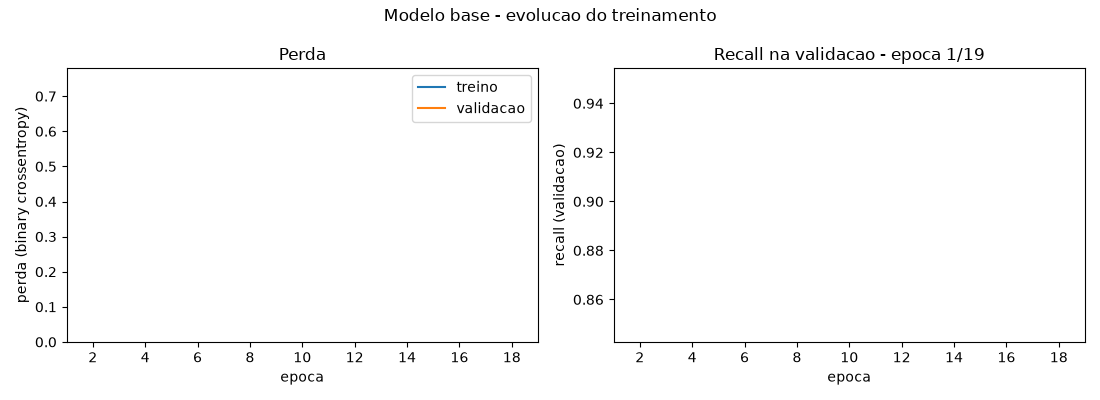

In [20]:
from IPython.display import Image, display

caminho_gif = gif_de_treinamento(
    historico_base, metrica_base.historico,
    os.path.join(PASTA_FIGURAS, 'treino_modelo_base.gif'),
    'Modelo base - evolucao do treinamento',
)
display(Image(filename=caminho_gif))

### Desempenho na validação

O limiar é 0,5, fixo. Não há nada a escolher aqui — esta célula só mostra como o modelo treinado se
comporta na validação antes de encostar no conjunto de teste.

In [21]:
probas_val_base = prever_probabilidades(modelo_base, X_val)

print("Modelo base na validacao (limiar 0.5):")
for chave, valor in metricas_binarias(y_val, probas_val_base, 'Base (frequencia)').items():
    if chave != 'modelo':
        print(f"  {chave:26s} {valor}")

print(f"\nDistribuicao das probabilidades previstas: "
      f"min {probas_val_base.min():.4f} | media {probas_val_base.mean():.4f} | "
      f"max {probas_val_base.max():.4f}")

Modelo base na validacao (limiar 0.5):
  recall                     0.9089
  contratantes capturados    708
  contratantes perdidos      71
  empresas sinalizadas       8962
  % da base abordada         28.8
  precisao                   0.079
  ganho sobre o acaso        3.16
  contatos por contratacao   12.7
  F1                         0.1454
  MCC                        0.2197
  Brier                      0.16247
  ROC-AUC                    0.8961
  PR-AUC                     0.1902

Distribuicao das probabilidades previstas: min 0.0099 | media 0.3290 | max 0.9928


### Avaliação no teste

O conjunto de teste é usado uma única vez, agora.

In [22]:
probas_teste_base = prever_probabilidades(modelo_base, X_teste)
resultado_base = metricas_binarias(y_teste, probas_teste_base, 'Base (frequencia)')

y_pred_base = (probas_teste_base >= LIMIAR).astype(int)
print(classification_report(y_teste, y_pred_base,
                            target_names=['Nao contratou', 'Contratou'], zero_division=0))
print(f"Dos {int(y_teste.sum())} contratantes do teste, o modelo capturou "
      f"{resultado_base['contratantes capturados']} e deixou passar "
      f"{resultado_base['contratantes perdidos']}.\n")
pd.DataFrame([resultado_base]).set_index('modelo').T

               precision    recall  f1-score   support

Nao contratou       1.00      0.73      0.84     30363
    Contratou       0.08      0.92      0.15       779

     accuracy                           0.73     31142
    macro avg       0.54      0.83      0.49     31142
 weighted avg       0.97      0.73      0.82     31142

Dos 779 contratantes do teste, o modelo capturou 720 e deixou passar 59.



modelo,Base (frequencia)
recall,0.92430
contratantes capturados,720.00000
contratantes perdidos,59.00000
empresas sinalizadas,9006.00000
% da base abordada,28.90000
precisao,0.07990
ganho sobre o acaso,3.20000
contatos por contratacao,12.50000
F1,0.14720
MCC,0.22440


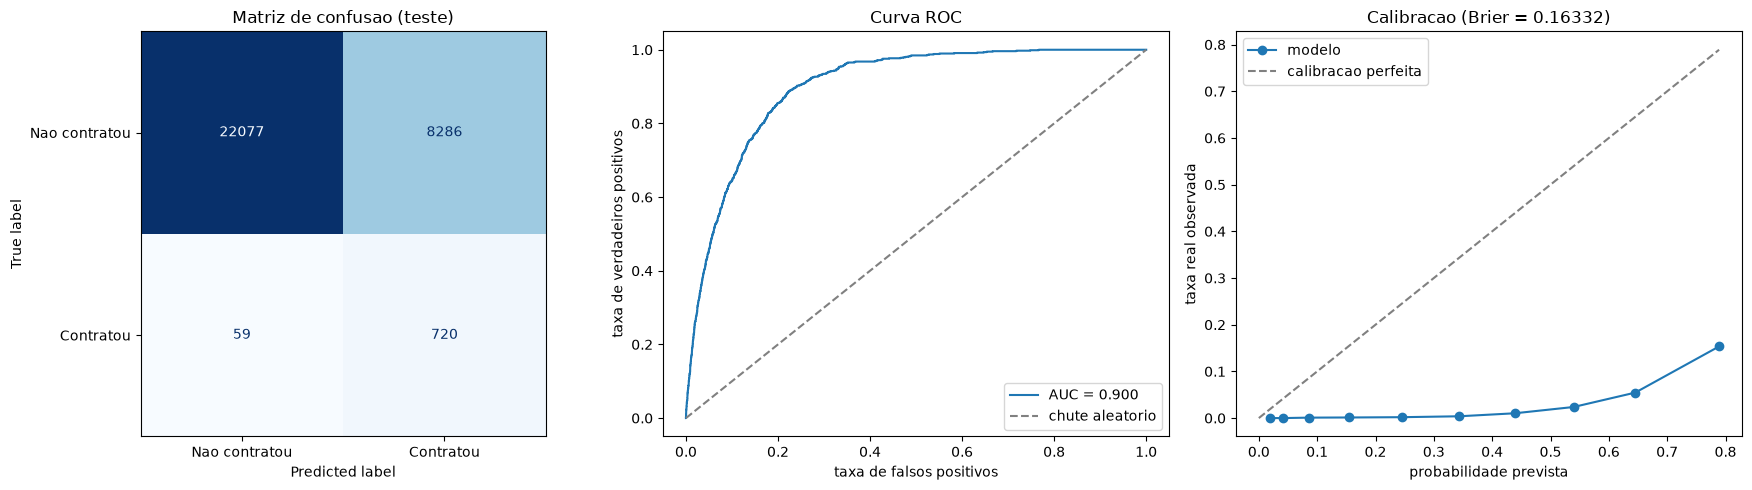

In [23]:
fig, eixos = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(confusion_matrix(y_teste, y_pred_base),
                       display_labels=['Nao contratou', 'Contratou']).plot(
    ax=eixos[0], colorbar=False, cmap='Blues')
eixos[0].set_title('Matriz de confusao (teste)')

fpr, tpr, _ = roc_curve(y_teste, probas_teste_base)
eixos[1].plot(fpr, tpr, label=f"AUC = {resultado_base['ROC-AUC']:.3f}")
eixos[1].plot([0, 1], [0, 1], '--', color='gray', label='chute aleatorio')
eixos[1].set_xlabel('taxa de falsos positivos'); eixos[1].set_ylabel('taxa de verdadeiros positivos')
eixos[1].set_title('Curva ROC'); eixos[1].legend()

# curva de calibracao: o quanto a probabilidade prevista corresponde a realidade
fracao_real, media_prevista = calibration_curve(y_teste, probas_teste_base, n_bins=10, strategy='quantile')
eixos[2].plot(media_prevista, fracao_real, 'o-', label='modelo')
eixos[2].plot([0, max(media_prevista)], [0, max(media_prevista)], '--', color='gray',
              label='calibracao perfeita')
eixos[2].set_xlabel('probabilidade prevista'); eixos[2].set_ylabel('taxa real observada')
eixos[2].set_title(f"Calibracao (Brier = {resultado_base['Brier']:.5f})"); eixos[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(PASTA_FIGURAS, 'avaliacao_modelo_base.png'), dpi=120)
plt.show()

## 11. Modelo com embeddings

Mesma tarefa, mesmos conjuntos, mesma configuração de peso — o que muda é como as variáveis
categóricas entram na rede. Os hiperparâmetros aqui são fixos (sem nova busca do Optuna), pra
manter o tempo de execução sob controle. A comparação continua justa porque os dois modelos veem
exatamente as mesmas empresas.

In [24]:
ent_treino, ent_val, ent_teste, tamanhos, artefatos_emb = preparar_dados_embeddings(
    treino, validacao, teste, FEATURES_NUMERICAS, FEATURES_CATEGORICAS
)

print("Vocabulario de cada variavel categorica (o indice 0 e reservado pra categoria nova):")
for nome, tamanho in tamanhos.items():
    dimensao = int(min(16, max(2, round(1.6 * tamanho ** 0.56))))
    print(f"  {nome:26s} {tamanho:>4} categorias -> vetor de dimensao {dimensao}")

Vocabulario de cada variavel categorica (o indice 0 e reservado pra categoria nova):
  ds_sebrae_segmento           21 categorias -> vetor de dimensao 9
  nm_municipio                168 categorias -> vetor de dimensao 16
  ds_tipo_estabelecimento       3 categorias -> vetor de dimensao 3
  sg_porte                      5 categorias -> vetor de dimensao 4


In [25]:
keras.backend.clear_session()
tf.random.set_seed(SEED)
modelo_emb = construir_modelo_embeddings(
    tamanhos_categoricas=tamanhos, n_numericas=len(FEATURES_NUMERICAS),
    n_camadas=2, unidades_iniciais=128, taxa_dropout=0.3,
    learning_rate=1e-3, otimizador_nome='adamw',
)
modelo_emb.summary()

callbacks_emb, metrica_emb = montar_callbacks(ent_val, y_val, paciencia=10)
historico_emb = modelo_emb.fit(
    ent_treino, y_treino, validation_data=(ent_val, y_val),
    epochs=60, batch_size=512, class_weight=PESOS_CLASSE,
    callbacks=callbacks_emb, verbose=1,
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ds_sebrae_segmento  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nm_municipio        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ds_tipo_estabeleci… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sg_porte            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_ds_sebra… │ (None, 1, 9)      │        189 │ ds_sebrae_segmen… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_nm_munic… │ (None, 1, 16)     │      2,688 │ nm_municipio[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_ds_tipo_… │ (None, 1, 3)      │          9 │ ds_tipo_estabele… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_sg_porte  │ (None, 1, 4)      │         20 │ sg_porte[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 9)         │          0 │ embedding_ds_seb… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16)        │          0 │ embedding_nm_mun… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 3)         │          0 │ embedding_ds_tip… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 4)         │          0 │ embedding_sg_por… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numericas           │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 35)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ numericas[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      4,608 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 16,603 (64.86 KB)

 Trainable params: 16,219 (63.36 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/60
284/284 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - auc: 0.8580 - loss: 0.4762 - val_auc: 0.9212 - val_loss: 0.3210 - val_recall: 0.8549
Epoch 2/60
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9023 - loss: 0.3911 - val_auc: 0.9244 - val_loss: 0.3538 - val_recall: 0.8922
Epoch 3/60
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - auc: 0.9092 - loss: 0.3762 - val_auc: 0.9245 - val_loss: 0.3575 - val_recall: 0.8922
Epoch 4/60
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - auc: 0.9121 - loss: 0.3698 - val_auc: 0.9243 - val_loss: 0.3685 - val_recall: 0.8986
Epoch 5/60
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9157 - loss: 0.3611 - val_auc: 0.9243 - val_loss: 0.3612 - val_recall: 0.8960
Epoch 6/60
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9170 - loss: 0.3574 - val_auc: 0.9242 - val_loss: 0.3582 - val_recall: 0.8909
Epoch 7/60
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9196 - loss: 0.3519 - val_auc: 0.9243 - val_loss: 0.3473 - val_recall: 0.8909
Epoch 8/60
284/284 ━━━━━━━━

In [26]:
probas_teste_emb = prever_probabilidades(modelo_emb, ent_teste)
resultado_emb = metricas_binarias(y_teste, probas_teste_emb, 'Embeddings')

comparacao = pd.DataFrame([resultado_base, resultado_emb]).set_index('modelo')
print(f"Comparacao no conjunto de teste (mesmo limiar de {LIMIAR} para os dois):")
comparacao.T

Comparacao no conjunto de teste (mesmo limiar de 0.5 para os dois):


modelo,Base (frequencia),Embeddings
recall,0.92430,0.90760
contratantes capturados,720.00000,707.00000
contratantes perdidos,59.00000,72.00000
empresas sinalizadas,9006.00000,6296.00000
% da base abordada,28.90000,20.20000
precisao,0.07990,0.11230
ganho sobre o acaso,3.20000,4.49000
contatos por contratacao,12.50000,8.90000
F1,0.14720,0.19990
MCC,0.22440,0.28130


In [27]:
# escolhe o modelo final pelo recall, o criterio do trabalho
MELHOR_MODELO = comparacao['recall'].idxmax()
modelo_final = modelo_base if MELHOR_MODELO == 'Base (frequencia)' else modelo_emb
probas_teste_final = probas_teste_base if MELHOR_MODELO == 'Base (frequencia)' else probas_teste_emb
resultado_final = resultado_base if MELHOR_MODELO == 'Base (frequencia)' else resultado_emb

print(f"Modelo final: {MELHOR_MODELO}")
print(f"  recall {resultado_final['recall']*100:.1f}% "
      f"({resultado_final['contratantes capturados']} capturados, "
      f"{resultado_final['contratantes perdidos']} perdidos)")
print(f"  {resultado_final['empresas sinalizadas']:,} empresas sinalizadas "
      f"({resultado_final['% da base abordada']}% da base)")

Modelo final: Base (frequencia)
  recall 92.4% (720 capturados, 59 perdidos)
  9,006 empresas sinalizadas (28.9% da base)


## 12. O ganho sobre o acaso

A estratégia atual captura 100% dos contratantes abordando 100% das empresas. A pergunta é quanto
desse esforço o modelo consegue cortar, e o quanto ele acerta mais que o acaso.

A tabela por faixa mostra a qualidade da ordenação: dividindo as empresas do teste em 10 grupos de
mesmo tamanho, do maior para o menor risco previsto, as primeiras faixas devem concentrar a maior
parte dos contratantes.

In [28]:
def tabela_de_ganhos(y_verdadeiro, probas, n_faixas=10):
    """ordena as empresas pela probabilidade prevista e mede a taxa de acerto por faixa"""
    ordem = np.argsort(-probas)
    y_ordenado = y_verdadeiro[ordem]
    taxa_base = y_verdadeiro.mean()
    total_contratantes = y_verdadeiro.sum()

    linhas, acumulado = [], 0
    for posicao, indices in enumerate(np.array_split(np.arange(len(y_ordenado)), n_faixas), start=1):
        bloco = y_ordenado[indices]
        acumulado += int(bloco.sum())
        linhas.append({
            'faixa': f'{posicao * 100 // n_faixas}% melhores',
            'empresas': len(bloco),
            'contratantes': int(bloco.sum()),
            'taxa de acerto (%)': round(bloco.mean() * 100, 2),
            'ganho sobre o acaso': round(bloco.mean() / taxa_base, 2),
            'contratantes capturados (%)': round(acumulado / total_contratantes * 100, 1),
        })
    return pd.DataFrame(linhas).set_index('faixa')


ganhos = tabela_de_ganhos(y_teste, probas_teste_final)
print(f"Taxa de acerto do acaso: {TAXA_ACERTO_ACASO*100:.2f}%\n")
ganhos

Taxa de acerto do acaso: 2.50%



,empresas,contratantes,taxa de acerto (%),ganho sobre o acaso,contratantes capturados (%)
faixa,,,,,
10% melhores,3115,478,15.35,6.13,61.4
20% melhores,3115,170,5.46,2.18,83.2
30% melhores,3114,74,2.38,0.95,92.7
40% melhores,3114,32,1.03,0.41,96.8
50% melhores,3114,12,0.39,0.15,98.3
60% melhores,3114,6,0.19,0.08,99.1
70% melhores,3114,4,0.13,0.05,99.6
80% melhores,3114,3,0.10,0.04,100.0
90% melhores,3114,0,0.00,0.00,100.0


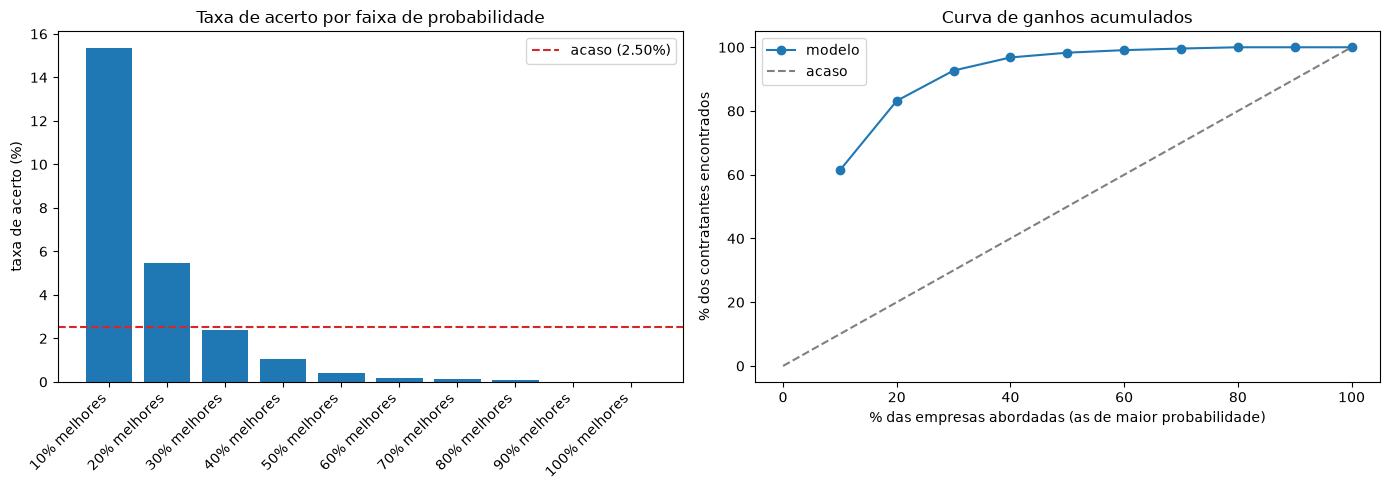

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

posicoes = np.arange(len(ganhos))
ax1.bar(posicoes, ganhos['taxa de acerto (%)'], color='tab:blue')
ax1.axhline(TAXA_ACERTO_ACASO * 100, color='tab:red', linestyle='--',
            label=f'acaso ({TAXA_ACERTO_ACASO*100:.2f}%)')
ax1.set_xticks(posicoes); ax1.set_xticklabels(ganhos.index, rotation=45, ha='right')
ax1.set_ylabel('taxa de acerto (%)'); ax1.set_title('Taxa de acerto por faixa de probabilidade')
ax1.legend()

# curva de ganhos acumulados: quantos contratantes se captura abordando os X% melhores
percentual_abordado = np.arange(1, len(ganhos) + 1) * (100 // len(ganhos))
ax2.plot(percentual_abordado, ganhos['contratantes capturados (%)'], 'o-', label='modelo')
ax2.plot([0, 100], [0, 100], '--', color='gray', label='acaso')
ax2.set_xlabel('% das empresas abordadas (as de maior probabilidade)')
ax2.set_ylabel('% dos contratantes encontrados')
ax2.set_title('Curva de ganhos acumulados'); ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(PASTA_FIGURAS, 'ganho_sobre_o_acaso.png'), dpi=120)
plt.show()

In [30]:
melhor_faixa = ganhos.iloc[0]

print("RESUMO (conjunto de teste, empresas que o modelo nunca viu)")
print("=" * 78)
print(f"Hoje, abordando na sorte: {TAXA_ACERTO_ACASO*100:.2f}% de acerto, "
      f"{1/TAXA_ACERTO_ACASO:.0f} contatos por contratacao.")
print(f"Capturar todos os {int(y_teste.sum())} contratantes sem modelo exige abordar as "
      f"{len(y_teste):,} empresas.\n")
print(f"Com o modelo ({MELHOR_MODELO}, limiar {LIMIAR}):")
print(f"  recall de {resultado_final['recall']*100:.1f}% - captura "
      f"{resultado_final['contratantes capturados']} dos {int(y_teste.sum())} contratantes")
print(f"  abordando {resultado_final['empresas sinalizadas']:,} empresas "
      f"({resultado_final['% da base abordada']}% da base) em vez de {len(y_teste):,}")
print(f"  {resultado_final['contatos por contratacao']} contatos por contratacao, "
      f"contra {1/TAXA_ACERTO_ACASO:.0f} do acaso")
print(f"  precisao {resultado_final['precisao']*100:.1f}% = "
      f"{resultado_final['ganho sobre o acaso']}x o acaso")
print(f"  deixa passar {resultado_final['contratantes perdidos']} contratantes\n")
print(f"Os 10% de maior probabilidade convertem a {melhor_faixa['taxa de acerto (%)']:.2f}% "
      f"({melhor_faixa['ganho sobre o acaso']:.1f}x o acaso) e ja contem "
      f"{melhor_faixa['contratantes capturados (%)']:.1f}% de todos os contratantes.")

RESUMO (conjunto de teste, empresas que o modelo nunca viu)
Hoje, abordando na sorte: 2.50% de acerto, 40 contatos por contratacao.
Capturar todos os 779 contratantes sem modelo exige abordar as 31,142 empresas.

Com o modelo (Base (frequencia), limiar 0.5):
  recall de 92.4% - captura 720 dos 779 contratantes
  abordando 9,006 empresas (28.9% da base) em vez de 31,142
  12.5 contatos por contratacao, contra 40 do acaso
  precisao 8.0% = 3.2x o acaso
  deixa passar 59 contratantes

Os 10% de maior probabilidade convertem a 15.35% (6.1x o acaso) e ja contem 61.4% de todos os contratantes.


## 13. Salvando o modelo

In [31]:
modelo_final.save(os.path.join(PASTA_MODELOS, 'propensao_consultoria.keras'))

# o pre-processador vai junto: sem ele nao da pra aplicar o modelo em dados novos
formato = salvar_artefatos({
    'tipo_modelo': MELHOR_MODELO,
    'limiar': LIMIAR,
    'taxa_base': float(TAXA_BASE),
    'pre_processador': pre_processador,
    'artefatos_embeddings': artefatos_emb,
    'features_numericas': FEATURES_NUMERICAS,
    'features_categoricas': FEATURES_CATEGORICAS,
    'melhores_hiperparametros': melhores_params,
    'modo_peso': MELHOR_PESO_NOME,
}, os.path.join(PASTA_MODELOS, 'propensao_artefatos.joblib'))

print(f"Modelo salvo em {PASTA_MODELOS}/ (artefatos serializados com {formato})")

joblib nao deu conta ('NoneType' object is not iterable); tentando com dill.
Modelo salvo em modelos/ (artefatos serializados com dill)


## 14. Discussão dos resultados

### O contra-peso é o que faz a rede conseguir decidir

Com o limiar fixo em 0,5, o experimento da seção 8 mostrou uma progressão bem clara na validação:

| contra-peso | recall | empresas sinalizadas | precisão | Brier | prob. média prevista |
|---|---|---|---|---|---|
| sem peso | 3,3% | 104 (0,3% da base) | 25,0% | 0,033 | 0,122 |
| suave (raiz do inverso) | 49,4% | 1.720 (5,5%) | 22,4% | 0,041 | 0,106 |
| balanceado (inverso) | **89,2%** | 7.009 (22,5%) | 9,9% | 0,137 | 0,266 |

Sem contra-peso a rede aprende que responder "não contrata" quase sempre erra pouco, e praticamente
ninguém cruza os 50%: 104 empresas sinalizadas em 31 mil. O peso balanceado foi o escolhido, por
recall, e é ele que viabiliza a decisão no limiar padrão.

O preço aparece na última coluna. A taxa real de contratação é 2,5%, mas o modelo com peso
balanceado prevê em média 26,6% — as probabilidades ficam infladas, e o Brier vai de 0,033 para
0,137 (a referência de quem responde sempre a taxa-base é 0,024). Ou seja: o número que a rede
devolve serve para **ordenar** empresas, não para ser lido como "esta empresa tem 26% de chance".

### Busca de hiperparâmetros

Foram 20 trials, 16 concluídos e 4 podados pelo `MedianPruner`, em 8 minutos e 38 segundos de CPU.
A configuração vencedora foi 3 camadas, 128 unidades iniciais, sem BatchNorm, dropout de 0,294,
learning rate 0,000105, AdamW e batch de 128, com recall de 91,1% na validação.

Vale registrar que a busca dispensou o BatchNorm e escolheu um learning rate baixo com dropout
moderado — combinação que, junto com o peso balanceado, favorece um modelo que erra para o lado de
sinalizar.

### Resultado no teste

No conjunto de teste, que nenhuma etapa do treino viu, o modelo base capturou **720 dos 779
contratantes — recall de 92,4%**, deixando passar 59. Para isso sinalizou 9.006 empresas, 28,9% da
base. A precisão ficou em 8,0%, ou 3,2 vezes a taxa-base de 2,5%. ROC-AUC de 0,900 e MCC de 0,224.

A tabela por faixa de probabilidade mostra que a ordenação funciona: os 10% de maior probabilidade
convertem a 15,35%, seis vezes o acaso, e concentram 61,4% de todos os contratantes. Nos 20%
melhores já estão 83,2% deles. Da metade da lista para baixo praticamente não há contratante algum.

Traduzindo para a operação: numa prospecção feita sem critério, seriam 40 contatos para cada
contratação. Seguindo a ordenação do modelo, são 12,5.

### As duas arquiteturas: onde o critério único mostra o limite

A comparação entre o modelo base e o modelo com embeddings foi o resultado mais interessante da
execução:

| | base (frequência) | embeddings |
|---|---|---|
| recall | **92,4%** | 90,8% |
| contratantes capturados | **720** | 707 |
| empresas sinalizadas | 9.006 | **6.296** |
| contatos por contratação | 12,5 | **8,9** |
| precisão | 8,0% | **11,2%** |
| MCC | 0,224 | **0,281** |
| ROC-AUC | 0,900 | **0,929** |
| PR-AUC | 0,190 | **0,260** |
| Brier | 0,163 | **0,124** |

O modelo com embeddings perde em recall e ganha em todo o resto. Ele captura 13 contratantes a
menos, mas sinaliza 2.710 empresas a menos — quase 30% menos esforço de abordagem para 1,8 ponto
percentual de recall.

O critério deste trabalho é recall, então **o modelo base é o escolhido**, e é ele que está salvo.
Mas a comparação deixa exposto o limite de olhar uma métrica só: se o critério fosse qualquer outro
da tabela, a decisão se inverteria. Aprender um vetor por município e por segmento, em vez de
resumir cada categoria à sua frequência, produziu uma ordenação melhor — o ROC-AUC sobe de 0,900
para 0,929 e o PR-AUC de 0,190 para 0,260. O que o modelo base tem de vantagem é ser mais
"generoso": ele empurra mais empresas para cima do limiar, e nesse movimento pega alguns
contratantes a mais junto com muitos não-contratantes.

## 15. Limitações

**O modelo aprendeu com um mundo reativo.** Hoje o Sebrae/RN não prospecta consultoria: o cliente
chega com a demanda. Logo, a base registra **quem costuma procurar** o serviço, e não quem aceitaria
uma oferta. São coisas parecidas, mas não são a mesma. O modelo é uma boa aproximação inicial, e a
única forma de medir a diferença é gerar dados de oferta — o que só acontece rodando um piloto.

**Recall como critério único tem um ponto cego, e ele apareceu nesta execução.** A comparação entre
as duas arquiteturas é o exemplo concreto: o modelo escolhido é o que sinaliza 43% mais empresas
para capturar 1,8 ponto percentual a mais de contratantes. Por isso todas as tabelas trazem, ao lado
do recall, quantas empresas o modelo mandou abordar — sem esse par, o número sozinho enganaria.

**A probabilidade prevista não é confiável em valor absoluto.** O contra-peso balanceado infla as
saídas: a média prevista é 26,6% para uma taxa real de 2,5%, e o Brier (0,163) fica bem acima da
referência (0,024). Serve para ranquear, não para informar "chance de contratação" a um usuário.

**A precisão é baixa em termos absolutos.** Das 9.006 empresas sinalizadas, cerca de 8% contratam.
É o esperado numa base com 2,5% de positivos, mas precisa estar claro para quem for usar: a lista é
um ponto de partida priorizado, não uma lista de vendas certas.

**O conjunto de variáveis é enxuto** — sete no total, todas de perfil cadastral e histórico de
atendimento. Não houve engenharia de atributos mais elaborada, como cruzamentos entre segmento e
município, sazonalidade ou histórico temporal por empresa.

**A base é um retrato estático:** não há informação de quando cada atendimento ou contratação
aconteceu, então o modelo não captura sazonalidade nem a ordem dos eventos. E é só do Sebrae/RN, de
modo que a generalização para outros estados não foi testada.

**Os hiperparâmetros do modelo com embeddings foram fixados**, e não buscados como no modelo base.
Dado que ele já venceu em quase tudo sem busca, é provável que esteja sendo subestimado.

## 16. Próximos passos

O passo que mais muda o jogo é **gerar dados de oferta**: um piloto em que um grupo de empresas
sinalizadas receba a abordagem e a resposta seja registrada. Isso resolve a limitação mais séria do
trabalho, porque passa a existir dado sobre reação à oferta, e não apenas sobre procura espontânea.

Do lado técnico, o caminho é engenharia de atributos sobre as variáveis existentes e uma busca de
hiperparâmetros também para a arquitetura com embeddings, que hoje compete em desvantagem.

Do lado do produto, o destino natural do modelo é o CRM. Num cenário hipotético, a probabilidade
apareceria para quem atende como um sinal de que vale aprofundar o relacionamento com aquele
cliente — não como uma ordem de venda.